# Mass transport–fluid coupling: compact Elder-type ensemble

This notebook is a **compact open-source canonical adaptation of the Multiphysics Bench Elder model**, not a bitwise or FEM-equivalent reproduction. It solves

$$
\epsilon\,\partial_t\rho+\nabla\cdot(\rho\mathbf u)=0,\qquad
\mathbf u=-\frac{K}{\mu}(\nabla p-\rho\mathbf g),
$$

$$
\epsilon\,\partial_t c+\nabla\cdot(\mathbf u c)
-\nabla\cdot(\epsilon D_L\nabla c)=S_c,\qquad
\rho=\rho_0+\beta\max(c,0).
$$

The centered domain is $[-150,150]\times[-75,75]$ m. Concentration is zero on the bottom and one on the top-right half; the other concentration boundaries have zero total species flux. Total Darcy mass flux is zero on every exterior face and pressure is given a zero-mean gauge. A Gaussian source drives concentration while density-dependent buoyancy updates the Darcy flow, so neither field is prescribed from the other.

The numerical adaptation replaces upstream COMSOL/FEM with a boundary-inclusive, conservative face-flux finite-volume-equivalent stencil. Advection is first-order upwind, diffusion is implicit, and pressure/density/concentration are Picard-coupled within adaptive internal steps. Because the stated closed mass boundary and concentration-driven density change are not globally compatible in a rigid incompressible pore volume, the constant component of the pressure-continuity right-hand side is projected out before applying the pressure gauge; the retained global mismatch is included in the mass diagnostic instead of being hidden.

Normal mode creates eight deterministic Sobol trajectories on a 128 × 128 grid at 0, 2, ..., 20 years. `PHYCOFLOW_VIZ_SMOKE=1` creates one 24 × 24 trajectory through year 4. Raw output remains in SI units, masks stay fixed through time, and nothing is saved unless the explicit export flag is enabled.

Adapted from *Multiphysics Bench: Benchmarking and Investigating Scientific Machine Learning for Multiphysics PDEs* (arXiv:2505.17575v1) and the MIT-licensed `xie-lab-ml/multiphysics-bench` code at commit `1195b44915712929d605ee5076a831c7124ead93`, especially `Elder.m` and the released Elder sparse-observation script.

The six-panel dashboard argues one conclusion: density-driven circulation, source transport, and sparse evidence remain synchronized in one transient realization. Level sets are a topology-oriented preview, not a persistent-homology implementation.


In [ ]:
import os
import json
import hashlib
from pathlib import Path

import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.stats import qmc
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

try:
    from IPython.display import HTML, display
except ImportError:  # Allows smoke validation as a plain Python script.
    HTML = None
    display = None

case_name = "mass_transport_fluid"
version_label = "compact-multiphysics-bench-v1"
upstream_commit = "1195b44915712929d605ee5076a831c7124ead93"
mass_transport_seed = 29
smoke_mode = os.environ.get("PHYCOFLOW_VIZ_SMOKE", "0") == "1"
save_compact_dataset = False
trajectory_index = 0

n = 24 if smoke_mode else 128  # 24^2 still accommodates 500 unique sensors.
sample_count = 1 if smoke_mode else 8
times_years = np.arange(0.0, 6.0 if smoke_mode else 22.0, 2.0, dtype=np.float64)
seconds_per_year = 365.0 * 24.0 * 60.0 * 60.0
rho0 = 1000.0
beta = 200.0
dynamic_viscosity = 1.0e-3
permeability = 4.9346165e-13
porosity = 0.1
diffusivity = 3.56e-6
surface_concentration = 1.0
gravity_y = -9.81
picard_tolerance = 2.0e-5
maximum_picard_iterations = 18
picard_relaxation = 0.65
advective_cfl = 0.45
maximum_step_years = 0.50 if smoke_mode else 0.25
minimum_step_years = 2.0e-4

channel_names = ("u_x", "u_y", "concentration")
channel_units = ("m/s", "m/s", "mol/m^3")
parameter_names = ("A", "x0", "y0", "s")
protocol_names = ("official_independent_500", "shared_500")

x = np.linspace(-150.0, 150.0, n, dtype=np.float64)
y = np.linspace(-75.0, 75.0, n, dtype=np.float64)
xx, yy = np.meshgrid(x, y, indexing="xy")
dx = x[1] - x[0]
dy = y[1] - y[0]

sobol = qmc.Sobol(d=4, scramble=True, seed=mass_transport_seed)
if smoke_mode:
    unit_parameters = sobol.random_base2(m=0)
else:
    unit_parameters = sobol.random_base2(m=3)
sample_parameters = qmc.scale(
    unit_parameters,
    [1.0e-3, -70.0, -30.0, 10.0],
    [8.0e-3, 70.0, 30.0, 70.0],
).astype(np.float64)


def gaussian_source(parameters):
    amplitude, center_x, center_y, width = parameters
    return amplitude / seconds_per_year * np.exp(
        -((xx - center_x) ** 2 + (yy - center_y) ** 2) / (2.0 * width**2)
    )


source_fields = np.asarray(
    [gaussian_source(parameters) for parameters in sample_parameters],
    dtype=np.float64,
)

bottom_dirichlet = np.zeros((n, n), dtype=bool)
bottom_dirichlet[0, :] = True
top_right_dirichlet = np.zeros((n, n), dtype=bool)
top_right_dirichlet[-1, x >= 0.0] = True
concentration_dirichlet = bottom_dirichlet | top_right_dirichlet
concentration_boundary_values = np.zeros((n, n), dtype=np.float64)
concentration_boundary_values[top_right_dirichlet] = surface_concentration



## Conservative coupled solver

Pressure rows discretize $-\nabla\cdot[(K/\mu)\rho\nabla p]$ and face buoyancy supplies the remaining Darcy mass flux. Exterior total mass flux is exactly zero. The singular Neumann system is pinned for the solve, then pressure is shifted to zero spatial mean.

Concentration uses the same face velocities, an upwind advective flux, and an implicit diffusion M-matrix. A step is rejected if nonlinear coupling fails, its CFL exceeds the target, or concentration becomes materially negative. Only tiny roundoff-scale undershoot is cleaned, after its pre-cleanup minimum has been recorded.


In [ ]:
def density_from_concentration(concentration):
    return rho0 + beta * np.maximum(concentration, 0.0)


def build_pressure_system(density, density_old, dt_seconds):
    """Return the variable-coefficient pressure operator and compatible RHS."""
    mobility = permeability / dynamic_viscosity
    rows, columns, values = [], [], []
    gravity_mass_x = np.zeros((n, n + 1), dtype=np.float64)
    gravity_mass_y = np.zeros((n + 1, n), dtype=np.float64)
    rho_x = 0.5 * (density[:, :-1] + density[:, 1:])
    rho_y = 0.5 * (density[:-1, :] + density[1:, :])
    gravity_mass_y[1:-1, :] = mobility * rho_y**2 * gravity_y

    for row in range(n):
        for column in range(n):
            index = row * n + column
            diagonal = 0.0
            if column > 0:
                coefficient = mobility * rho_x[row, column - 1] / dx**2
                diagonal += coefficient
                rows.append(index); columns.append(index - 1); values.append(-coefficient)
            if column < n - 1:
                coefficient = mobility * rho_x[row, column] / dx**2
                diagonal += coefficient
                rows.append(index); columns.append(index + 1); values.append(-coefficient)
            if row > 0:
                coefficient = mobility * rho_y[row - 1, column] / dy**2
                diagonal += coefficient
                rows.append(index); columns.append(index - n); values.append(-coefficient)
            if row < n - 1:
                coefficient = mobility * rho_y[row, column] / dy**2
                diagonal += coefficient
                rows.append(index); columns.append(index + n); values.append(-coefficient)
            rows.append(index); columns.append(index); values.append(diagonal)

    operator = sp.csr_matrix((values, (rows, columns)), shape=(n * n, n * n))
    gravity_divergence = (
        (gravity_mass_x[:, 1:] - gravity_mass_x[:, :-1]) / dx
        + (gravity_mass_y[1:, :] - gravity_mass_y[:-1, :]) / dy
    )
    unprojected_rhs = (
        -porosity * (density - density_old) / dt_seconds - gravity_divergence
    )
    compatibility_mismatch = float(unprojected_rhs.mean())
    right_hand_side = unprojected_rhs - compatibility_mismatch

    # A single gauge row makes the Neumann matrix nonsingular. The final shift
    # restores the requested zero spatial mean without changing fluxes.
    operator = operator.tolil()
    operator[0, :] = 0.0
    operator[0, 0] = 1.0
    right_hand_side = right_hand_side.ravel()
    right_hand_side[0] = 0.0
    return operator.tocsc(), right_hand_side, compatibility_mismatch


def darcy_face_fluxes(pressure, density):
    """Return face velocity and total mass flux; exterior faces remain zero."""
    mobility = permeability / dynamic_viscosity
    velocity_x = np.zeros((n, n + 1), dtype=np.float64)
    velocity_y = np.zeros((n + 1, n), dtype=np.float64)
    rho_x = 0.5 * (density[:, :-1] + density[:, 1:])
    rho_y = 0.5 * (density[:-1, :] + density[1:, :])
    velocity_x[:, 1:-1] = -mobility * (pressure[:, 1:] - pressure[:, :-1]) / dx
    velocity_y[1:-1, :] = -mobility * (
        (pressure[1:, :] - pressure[:-1, :]) / dy - rho_y * gravity_y
    )
    mass_flux_x = np.zeros_like(velocity_x)
    mass_flux_y = np.zeros_like(velocity_y)
    mass_flux_x[:, 1:-1] = rho_x * velocity_x[:, 1:-1]
    mass_flux_y[1:-1, :] = rho_y * velocity_y[1:-1, :]
    return velocity_x, velocity_y, mass_flux_x, mass_flux_y


def cell_velocity(velocity_x, velocity_y):
    return (
        0.5 * (velocity_x[:, :-1] + velocity_x[:, 1:]),
        0.5 * (velocity_y[:-1, :] + velocity_y[1:, :]),
    )


def upwind_species_flux(concentration, velocity_x, velocity_y):
    flux_x = np.zeros_like(velocity_x)
    flux_y = np.zeros_like(velocity_y)
    flux_x[:, 1:-1] = velocity_x[:, 1:-1] * np.where(
        velocity_x[:, 1:-1] >= 0.0, concentration[:, :-1], concentration[:, 1:]
    )
    flux_y[1:-1, :] = velocity_y[1:-1, :] * np.where(
        velocity_y[1:-1, :] >= 0.0, concentration[:-1, :], concentration[1:, :]
    )
    return flux_x, flux_y


def build_transport_operator(dt_seconds):
    rows, columns, values = [], [], []
    transient = porosity / dt_seconds
    diffusion_x = porosity * diffusivity / dx**2
    diffusion_y = porosity * diffusivity / dy**2
    for row in range(n):
        for column in range(n):
            index = row * n + column
            if concentration_dirichlet[row, column]:
                rows.append(index); columns.append(index); values.append(1.0)
                continue
            diagonal = transient
            if column > 0:
                diagonal += diffusion_x
                rows.append(index); columns.append(index - 1); values.append(-diffusion_x)
            if column < n - 1:
                diagonal += diffusion_x
                rows.append(index); columns.append(index + 1); values.append(-diffusion_x)
            if row > 0:
                diagonal += diffusion_y
                rows.append(index); columns.append(index - n); values.append(-diffusion_y)
            if row < n - 1:
                diagonal += diffusion_y
                rows.append(index); columns.append(index + n); values.append(-diffusion_y)
            rows.append(index); columns.append(index); values.append(diagonal)
    return sp.csc_matrix((values, (rows, columns)), shape=(n * n, n * n))


def solve_transport(concentration_old, concentration_for_flux, source, velocity_x, velocity_y, dt_seconds):
    flux_x, flux_y = upwind_species_flux(
        concentration_for_flux, velocity_x, velocity_y
    )
    advective_divergence = (
        (flux_x[:, 1:] - flux_x[:, :-1]) / dx
        + (flux_y[1:, :] - flux_y[:-1, :]) / dy
    )
    rhs = porosity / dt_seconds * concentration_old + source - advective_divergence
    rhs = rhs.ravel()
    rhs[concentration_dirichlet.ravel()] = concentration_boundary_values.ravel()[
        concentration_dirichlet.ravel()
    ]
    candidate = spla.spsolve(build_transport_operator(dt_seconds), rhs).reshape(n, n)
    return candidate, flux_x, flux_y


def coupled_step(concentration_old, source, dt_seconds):
    concentration = concentration_old.copy()
    density_old = density_from_concentration(concentration_old)
    minimum_before_cleanup = np.inf
    compatibility_mismatch = 0.0
    for iteration in range(1, maximum_picard_iterations + 1):
        density = density_from_concentration(concentration)
        pressure_operator, pressure_rhs, compatibility_mismatch = build_pressure_system(
            density, density_old, dt_seconds
        )
        pressure = spla.spsolve(pressure_operator, pressure_rhs).reshape(n, n)
        pressure -= pressure.mean()
        velocity_x, velocity_y, mass_flux_x, mass_flux_y = darcy_face_fluxes(
            pressure, density
        )
        candidate, species_flux_x, species_flux_y = solve_transport(
            concentration_old, concentration, source, velocity_x, velocity_y, dt_seconds
        )
        minimum_before_cleanup = min(minimum_before_cleanup, float(candidate.min()))
        if not np.isfinite(candidate).all() or candidate.min() < -1.0e-7:
            return None
        relaxed = concentration + picard_relaxation * (candidate - concentration)
        relaxed[concentration_dirichlet] = concentration_boundary_values[
            concentration_dirichlet
        ]
        concentration_update = np.max(np.abs(relaxed - concentration)) / (
            max(np.max(np.abs(relaxed)), surface_concentration) + 1.0e-30
        )
        density_update = np.max(
            np.abs(density_from_concentration(relaxed) - density)
        ) / (np.max(density_from_concentration(relaxed)) + 1.0e-30)
        concentration = relaxed
        if max(concentration_update, density_update) < picard_tolerance:
            break
    else:
        return None

    density = density_from_concentration(concentration)
    pressure_operator, pressure_rhs, compatibility_mismatch = build_pressure_system(
        density, density_old, dt_seconds
    )
    pressure = spla.spsolve(pressure_operator, pressure_rhs).reshape(n, n)
    pressure -= pressure.mean()
    velocity_x, velocity_y, mass_flux_x, mass_flux_y = darcy_face_fluxes(
        pressure, density
    )
    speed_x, speed_y = cell_velocity(velocity_x, velocity_y)
    speed = np.sqrt(speed_x**2 + speed_y**2)
    courant = float(speed.max() * dt_seconds / (porosity * min(dx, dy)))
    if courant > advective_cfl * (1.0 + 1.0e-10):
        return None
    # Only tolerance-scale undershoot is cleaned, after recording it above.
    concentration[(concentration < 0.0) & (concentration >= -1.0e-7)] = 0.0
    species_flux_x, species_flux_y = upwind_species_flux(
        concentration, velocity_x, velocity_y
    )
    return {
        "concentration": concentration,
        "pressure": pressure,
        "velocity_x_face": velocity_x,
        "velocity_y_face": velocity_y,
        "mass_flux_x": mass_flux_x,
        "mass_flux_y": mass_flux_y,
        "species_flux_x": species_flux_x,
        "species_flux_y": species_flux_y,
        "iterations": iteration,
        "courant": courant,
        "minimum_before_cleanup": minimum_before_cleanup,
        "compatibility_mismatch": compatibility_mismatch,
    }


def initial_state():
    concentration = np.zeros((n, n), dtype=np.float64)
    concentration[concentration_dirichlet] = concentration_boundary_values[
        concentration_dirichlet
    ]
    pressure = rho0 * gravity_y * yy
    pressure -= pressure.mean()
    zeros_x = np.zeros((n, n + 1), dtype=np.float64)
    zeros_y = np.zeros((n + 1, n), dtype=np.float64)
    return concentration, pressure, zeros_x, zeros_y


def simulate_trajectory(source):
    concentration, pressure, velocity_x, velocity_y = initial_state()
    ux, uy = cell_velocity(velocity_x, velocity_y)
    frames = [np.stack((ux, uy, concentration))]
    pressure_frames = [pressure.copy()]
    velocity_x_frames = [velocity_x.copy()]
    velocity_y_frames = [velocity_y.copy()]
    minimum_before_cleanup = float(concentration.min())
    iteration_counts = []
    compatibility_mismatches = []
    reduced_steps = 0
    rejected_steps = 0
    current_time = 0.0
    proposed_step = maximum_step_years

    for target_time in times_years[1:]:
        while current_time < target_time - 1.0e-12:
            step_years = min(proposed_step, target_time - current_time)
            while True:
                result = coupled_step(
                    concentration, source, step_years * seconds_per_year
                )
                if result is not None:
                    break
                rejected_steps += 1
                reduced_steps += 1
                step_years *= 0.5
                if step_years < minimum_step_years:
                    raise RuntimeError(
                        "adaptive Elder step fell below the minimum after nonlinear/CFL rejection"
                    )
            if step_years < proposed_step - 1.0e-14:
                reduced_steps += 1
            concentration = result["concentration"]
            pressure = result["pressure"]
            velocity_x = result["velocity_x_face"]
            velocity_y = result["velocity_y_face"]
            current_time += step_years
            minimum_before_cleanup = min(
                minimum_before_cleanup, result["minimum_before_cleanup"]
            )
            iteration_counts.append(result["iterations"])
            compatibility_mismatches.append(result["compatibility_mismatch"])
            if result["courant"] < 0.55 * advective_cfl:
                proposed_step = min(maximum_step_years, step_years * 1.35)
            else:
                proposed_step = step_years

        ux, uy = cell_velocity(velocity_x, velocity_y)
        frames.append(np.stack((ux, uy, concentration)))
        pressure_frames.append(pressure.copy())
        velocity_x_frames.append(velocity_x.copy())
        velocity_y_frames.append(velocity_y.copy())

    return {
        "trajectory": np.asarray(frames, dtype=np.float64),
        "pressure": np.asarray(pressure_frames, dtype=np.float64),
        "velocity_x_face": np.asarray(velocity_x_frames, dtype=np.float64),
        "velocity_y_face": np.asarray(velocity_y_frames, dtype=np.float64),
        "minimum_before_cleanup": minimum_before_cleanup,
        "iteration_counts": iteration_counts,
        "compatibility_mismatches": compatibility_mismatches,
        "reduced_steps": reduced_steps,
        "rejected_steps": rejected_steps,
    }


simulation_results = [simulate_trajectory(source) for source in source_fields]
trajectories = np.asarray(
    [result["trajectory"] for result in simulation_results], dtype=np.float64
)
fields = trajectories[trajectory_index]
# trajectories: [sample, time, channel=(u_x,u_y,c), y, x]
# fields: one selected realization [time, channel, y, x]



## Fixed sparse observations, ensemble normalization, and metrics

The official protocol uses independent fixed spatial masks for $u_x$ (seed 2), $u_y$ (seed 1), and $c$ (seed 0). The shared ablation uses seed 0 for every channel. Each mask contains exactly 500 locations and broadcasts across every sample and time without archive duplication.

Offsets and robust 99th-percentile scales are estimated once from the first half of the deterministic ensemble. Concentration uses the fixed physical scale $c_s=1$. Metrics operate on unobserved points per channel and never average unlike units before scaling.


In [ ]:
def sensor_indices(seed):
    return np.random.default_rng(seed).choice(n * n, 500, replace=False)


sensor_indices_official = np.stack(
    (sensor_indices(2), sensor_indices(1), sensor_indices(0))
)
shared_indices = sensor_indices(0)
sensor_indices_shared = np.stack((shared_indices, shared_indices, shared_indices))


def indices_to_masks(indices):
    masks = np.zeros((len(channel_names), n * n), dtype=bool)
    for channel, channel_indices in enumerate(indices):
        masks[channel, channel_indices] = True
    return masks.reshape(len(channel_names), n, n)


sensor_masks = np.stack(
    (indices_to_masks(sensor_indices_official), indices_to_masks(sensor_indices_shared))
)
sensor_coordinates = np.empty((2, len(channel_names), 500, 2), dtype=np.float64)
for protocol in range(2):
    indices = sensor_indices_official if protocol == 0 else sensor_indices_shared
    for channel in range(len(channel_names)):
        rows, columns = np.unravel_index(indices[channel], (n, n))
        sensor_coordinates[protocol, channel] = np.column_stack((x[columns], y[rows]))

training_count = max(1, sample_count // 2)
training_fields = trajectories[:training_count]
channel_offset = np.asarray(
    [training_fields[:, :, 0].mean(), training_fields[:, :, 1].mean(), 0.0],
    dtype=np.float64,
)
channel_scale = np.asarray(
    [
        max(
            np.quantile(
                np.abs(training_fields[:, :, channel] - channel_offset[channel]),
                0.99,
            ),
            1.0e-16,
        )
        for channel in range(2)
    ]
    + [surface_concentration],
    dtype=np.float64,
)
normalized = (trajectories - channel_offset[None, None, :, None, None]) / channel_scale[
    None, None, :, None, None
]
observations = np.where(
    sensor_masks[:, None, None, :, :, :],
    normalized[None, :, :, :, :, :],
    np.nan,
)


def reconstruction_metrics(prediction, target, mask):
    """Per-channel unobserved errors plus noiseless observed-point consistency."""
    prediction = np.asarray(prediction)
    target = np.asarray(target)
    mask = np.asarray(mask, dtype=bool)
    relative_l2, normalized_rmse, observed_consistency = [], [], []
    for channel in range(target.shape[0]):
        unseen = ~mask[channel]
        error = prediction[channel, unseen] - target[channel, unseen]
        relative_l2.append(
            np.linalg.norm(error) / (np.linalg.norm(target[channel, unseen]) + 1.0e-30)
        )
        normalized_rmse.append(
            np.sqrt(np.mean(error**2)) / (np.std(target[channel, unseen]) + 1.0e-30)
        )
        observed_consistency.append(
            np.sqrt(
                np.mean(
                    (prediction[channel, mask[channel]] - target[channel, mask[channel]]) ** 2
                )
            )
        )
    return {
        "relative_l2_unobserved": np.asarray(relative_l2),
        "normalized_rmse_unobserved": np.asarray(normalized_rmse),
        "observed_consistency_rmse": np.asarray(observed_consistency),
    }


def joint_sliced_wasserstein_inputs(field):
    return np.moveaxis(np.asarray(field), 0, -1).reshape(-1, len(channel_names))


def radial_spectral_error_inputs(prediction, target):
    window = np.outer(np.hanning(n), np.hanning(n))
    modes = np.fft.fftfreq(n) * n
    mx, my = np.meshgrid(modes, modes, indexing="xy")
    shell = np.sqrt(mx**2 + my**2).astype(int)
    outputs = []
    for data in (prediction, target):
        spectra = []
        for channel in range(len(channel_names)):
            centered = (data[channel] - data[channel].mean()) * window
            power = np.abs(np.fft.fft2(centered)) ** 2 / centered.size**2
            total = np.bincount(shell.ravel(), weights=power.ravel())
            count = np.maximum(np.bincount(shell.ravel()), 1)
            spectra.append(total / count)
        outputs.append(np.stack(spectra, axis=-1))
    return tuple(outputs)


def upstream_merged_compatibility(sample_index=0):
    """Optional legacy order: source, all ux times, all uy times, all c times."""
    selected = trajectories[sample_index]
    return np.concatenate(
        (source_fields[sample_index][None], selected[:, 0], selected[:, 1], selected[:, 2]),
        axis=0,
    )



## Flux-based numerical and data diagnostics

Centered temporal residuals use only interior recorded times. Spatial divergence is reconstructed from the solver's face velocities, not from zero-padded image derivatives. The boundary diagnostic is separate and uses the exterior numerical faces. The continuity diagnostic intentionally retains the global compatibility mismatch described above.


In [ ]:
def divergence(face_x, face_y):
    return (
        (face_x[:, 1:] - face_x[:, :-1]) / dx
        + (face_y[1:, :] - face_y[:-1, :]) / dy
    )


mass_residuals = []
transport_residuals = []
boundary_flux_residuals = []
maximum_pressure_mean = 0.0
for sample_index, result in enumerate(simulation_results):
    trajectory = result["trajectory"]
    pressure_frames = result["pressure"]
    vx_frames = result["velocity_x_face"]
    vy_frames = result["velocity_y_face"]
    maximum_pressure_mean = max(
        maximum_pressure_mean,
        max(abs(float(pressure.mean())) for pressure in pressure_frames),
    )
    for frame_index in range(1, len(times_years) - 1):
        dt_centered = (
            times_years[frame_index + 1] - times_years[frame_index - 1]
        ) * seconds_per_year
        previous_c = trajectory[frame_index - 1, 2]
        current_c = trajectory[frame_index, 2]
        next_c = trajectory[frame_index + 1, 2]
        previous_rho = density_from_concentration(previous_c)
        current_rho = density_from_concentration(current_c)
        next_rho = density_from_concentration(next_c)
        vx = vx_frames[frame_index]
        vy = vy_frames[frame_index]
        rho_x = np.zeros_like(vx)
        rho_y = np.zeros_like(vy)
        rho_x[:, 1:-1] = 0.5 * (current_rho[:, :-1] + current_rho[:, 1:])
        rho_y[1:-1, :] = 0.5 * (current_rho[:-1, :] + current_rho[1:, :])
        temporal_mass = porosity * (next_rho - previous_rho) / dt_centered
        mass_divergence = divergence(rho_x * vx, rho_y * vy)
        mass_residuals.append(
            np.linalg.norm(temporal_mass + mass_divergence)
            / (np.linalg.norm(temporal_mass) + np.linalg.norm(mass_divergence) + 1.0e-30)
        )

        temporal_transport = porosity * (next_c - previous_c) / dt_centered
        species_x, species_y = upwind_species_flux(current_c, vx, vy)
        advective_transport = divergence(species_x, species_y)
        diffusion_transport = np.zeros_like(current_c)
        diffusion_transport[1:-1, 1:-1] = -porosity * diffusivity * (
            (current_c[1:-1, 2:] - 2.0 * current_c[1:-1, 1:-1] + current_c[1:-1, :-2]) / dx**2
            + (current_c[2:, 1:-1] - 2.0 * current_c[1:-1, 1:-1] + current_c[:-2, 1:-1]) / dy**2
        )
        transport_residual = (
            temporal_transport + advective_transport + diffusion_transport - source_fields[sample_index]
        )[1:-1, 1:-1]
        pieces = (
            temporal_transport[1:-1, 1:-1],
            advective_transport[1:-1, 1:-1],
            diffusion_transport[1:-1, 1:-1],
            source_fields[sample_index, 1:-1, 1:-1],
        )
        transport_residuals.append(
            np.linalg.norm(transport_residual)
            / (sum(np.linalg.norm(piece) for piece in pieces) + 1.0e-30)
        )

        exterior_mass = np.concatenate((
            (rho_x * vx)[:, 0], (rho_x * vx)[:, -1],
            (rho_y * vy)[0, :], (rho_y * vy)[-1, :],
        ))
        exterior_species = np.concatenate((
            species_x[:, 0], species_x[:, -1], species_y[0, x < 0.0],
        ))
        boundary_flux_residuals.append(
            (np.linalg.norm(exterior_mass) + np.linalg.norm(exterior_species))
            / (
                np.linalg.norm(rho_x * vx)
                + np.linalg.norm(rho_y * vy)
                + np.linalg.norm(species_x)
                + np.linalg.norm(species_y)
                + 1.0e-30
            )
        )

deterministic_parameter_hash = hashlib.sha256(
    np.ascontiguousarray(sample_parameters).tobytes()
).hexdigest()
diagnostics = {
    "finite": bool(np.isfinite(trajectories).all()),
    "minimum_concentration_before_tolerance_cleanup": float(
        min(result["minimum_before_cleanup"] for result in simulation_results)
    ),
    "maximum_concentration": float(trajectories[:, :, 2].max()),
    "maximum_density": float(density_from_concentration(trajectories[:, :, 2]).max()),
    "maximum_speed": float(
        np.sqrt(trajectories[:, :, 0] ** 2 + trajectories[:, :, 1] ** 2).max()
    ),
    "relative_mass_balance_residual": float(max(mass_residuals, default=0.0)),
    "relative_transport_residual": float(max(transport_residuals, default=0.0)),
    "relative_boundary_flux_residual": float(max(boundary_flux_residuals, default=0.0)),
    "maximum_pressure_mean": float(maximum_pressure_mean),
    "maximum_picard_iterations": int(
        max((max(result["iteration_counts"], default=0) for result in simulation_results), default=0)
    ),
    "reduced_timestep_count": int(sum(result["reduced_steps"] for result in simulation_results)),
    "rejected_timestep_count": int(sum(result["rejected_steps"] for result in simulation_results)),
    "maximum_continuity_compatibility_projection": float(
        max(
            (max(np.abs(result["compatibility_mismatches"]), default=0.0) for result in simulation_results),
            default=0.0,
        )
    ),
    "sensor_count_per_channel": tuple(int(mask.sum()) for mask in sensor_masks[0]),
    "deterministic_parameter_hash": deterministic_parameter_hash,
}

assert trajectories.shape == (sample_count, len(times_years), 3, n, n)
assert fields.shape == (len(times_years), 3, n, n)
assert source_fields.shape == (sample_count, n, n)
assert sample_parameters.shape == (sample_count, 4)
assert diagnostics["finite"]
assert diagnostics["sensor_count_per_channel"] == (500, 500, 500)
assert diagnostics["minimum_concentration_before_tolerance_cleanup"] >= -1.0e-7
assert np.allclose(trajectories[:, :, 2, 0, :], 0.0)
assert np.allclose(trajectories[:, :, 2, -1, x >= 0.0], surface_concentration)
diagnostics



## Optional compact export

Nothing is saved by default. Enabling `save_compact_dataset` writes one compressed float32 NPZ and one provenance JSON, without duplicating normalized fields or time-broadcast masks. The archive is rejected if it exceeds 64 MiB.


In [ ]:
export_metadata = None
if save_compact_dataset:
    output_npz = Path("mass_transport_fluid_compact.npz")
    np.savez_compressed(
        output_npz,
        trajectories=trajectories.astype(np.float32),
        x=x,
        y=y,
        times=times_years,
        sample_parameters=sample_parameters,
        source_fields=source_fields.astype(np.float32),
        sensor_indices_official=sensor_indices_official,
        sensor_indices_shared=sensor_indices_shared,
        channel_offset=channel_offset,
        channel_scale=channel_scale,
    )
    if output_npz.stat().st_size > 64 * 2**20:
        raise RuntimeError("compact mass-transport archive exceeds 64 MiB")
    archive_hash = hashlib.sha256(output_npz.read_bytes()).hexdigest()
    export_metadata = {
        "case_name": case_name,
        "version_label": version_label,
        "channel_names": channel_names,
        "channel_units": channel_units,
        "parameter_names": parameter_names,
        "seed": mass_transport_seed,
        "upstream_commit": upstream_commit,
        "source_urls": [
            "https://arxiv.org/abs/2505.17575",
            "https://github.com/xie-lab-ml/multiphysics-bench",
        ],
        "grid_shape": [n, n],
        "times_years": times_years.tolist(),
        "picard_tolerance": picard_tolerance,
        "sha256": archive_hash,
    }
    Path("mass_transport_fluid_compact.json").write_text(
        json.dumps(export_metadata, indent=2), encoding="utf-8"
    )



## Six-panel transient sparse-reconstruction audit

The dashboard advances through the canonical output times for `trajectory_index`. Spatial masks do not move. Spectra are shell averages of Hann-windowed non-periodic fields, and the source marker makes transport relative to forcing immediately inspectable.


In [ ]:
def shell_spectrum(field):
    window = np.outer(np.hanning(n), np.hanning(n))
    centered = (field - field.mean()) * window
    power = np.abs(np.fft.fft2(centered)) ** 2 / centered.size**2
    modes = np.fft.fftfreq(n) * n
    mx, my = np.meshgrid(modes, modes, indexing="xy")
    shell = np.sqrt(mx**2 + my**2).astype(int)
    total = np.bincount(shell.ravel(), weights=power.ravel())
    count = np.maximum(np.bincount(shell.ravel()), 1)
    return np.arange(total.size), total / count


def draw_frame(frame_index, axes):
    for axis in axes.ravel():
        axis.clear()
    ux, uy, concentration = trajectories[trajectory_index, frame_index]
    extent = (x[0], x[-1], y[0], y[-1])
    for axis, field, title, mask, cmap in (
        (axes[0, 0], concentration, "Concentration", sensor_masks[0, 2], "viridis"),
        (axes[0, 1], ux, r"$u_x$", sensor_masks[0, 0], "RdBu_r"),
        (axes[0, 2], uy, r"$u_y$", sensor_masks[0, 1], "RdBu_r"),
    ):
        axis.imshow(field, origin="lower", extent=extent, cmap=cmap, aspect="equal")
        rows, columns = np.nonzero(mask)
        axis.scatter(x[columns], y[rows], s=2, c="white", alpha=0.45, linewidths=0)
        axis.set(xlabel="x [m]", ylabel="y [m]", title=title)

    stride = max(1, n * n // 2500)
    cloud = axes[1, 0].scatter(
        ux.ravel()[::stride],
        uy.ravel()[::stride],
        c=concentration.ravel()[::stride],
        s=6,
        cmap="viridis",
        alpha=0.45,
    )
    axes[1, 0].set(
        xlabel=r"$u_x$ [m/s]",
        ylabel=r"$u_y$ [m/s]",
        title="Joint velocity/concentration cloud",
    )
    kinetic_energy = 0.5 * (ux**2 + uy**2)
    radius_ke, spectrum_ke = shell_spectrum(kinetic_energy)
    radius_c, spectrum_c = shell_spectrum(concentration)
    axes[1, 1].semilogy(radius_ke[1:], spectrum_ke[1:] + 1.0e-30, label="kinetic energy")
    axes[1, 1].semilogy(radius_c[1:], spectrum_c[1:] + 1.0e-30, label="concentration")
    axes[1, 1].set(
        xlabel="radial grid-frequency shell",
        ylabel="windowed shell mean power",
        title="Flow/transport spectra",
    )
    axes[1, 1].legend()

    axes[1, 2].contour(xx, yy, concentration, levels=np.linspace(0.05, 0.95, 7), cmap="viridis")
    speed = np.sqrt(ux**2 + uy**2)
    if speed.max() > 0.0:
        axes[1, 2].streamplot(x, y, ux, uy, color="0.25", density=0.8, linewidth=0.6)
    _, source_x, source_y, _ = sample_parameters[trajectory_index]
    axes[1, 2].scatter([source_x], [source_y], marker="*", s=80, c="tab:red", label="source center")
    axes[1, 2].set(
        xlabel="x [m]",
        ylabel="y [m]",
        aspect="equal",
        title=f"Level sets and Darcy flow; t={times_years[frame_index]:.0f} y",
    )
    axes[1, 2].legend(loc="lower left", fontsize=7)
    return [cloud]


dashboard = None
if not smoke_mode and HTML is not None:
    figure, dashboard_axes = plt.subplots(
        2, 3, figsize=(12, 7), dpi=72, constrained_layout=True
    )
    animation = FuncAnimation(
        figure,
        lambda index: draw_frame(index, dashboard_axes),
        frames=np.arange(len(times_years)),
        interval=350,
        repeat=True,
    )
    plt.close(figure)
    dashboard = HTML(animation.to_jshtml(default_mode="once"))
    display(dashboard)


## Validated script-pipeline demo

The embedded panel below was generated by the standalone pipeline, not by the in-notebook solver: one 32 × 32 Sobol trajectory at 0, 2, and 4 years was written to checksummed raw NPZ/JSON, converted to unified HDF5, and rendered from the processed tensor dataset. It verifies source-relative transport fronts, both Darcy components, circulation, accumulation, and coupled spatial scales.

```bash
conda run -n phycoflow_env python datagen/6_mass_transport_fluid/generate.py --backend numpy --device cpu --resolution 32 --record-time 4 --dt 0.5 --save-every 4 --num-trajectories 1 --dataset-id mass_transport_demo
conda run -n phycoflow_env python datagen/6_mass_transport_fluid/postprocessing.py --raw-dir datagen/data/raw/mass_transport_fluid/mass_transport_demo --output datagen/data/processed/mass_transport_fluid_demo.h5 --split-ratios 1 0 0
conda run -n phycoflow_env python datagen/6_mass_transport_fluid/visualize.py --input datagen/data/processed/mass_transport_fluid_demo.h5 --trajectory 0 --time-index -1 --output datagen/data/demos/mass_transport_fluid_demo_qa.png
```


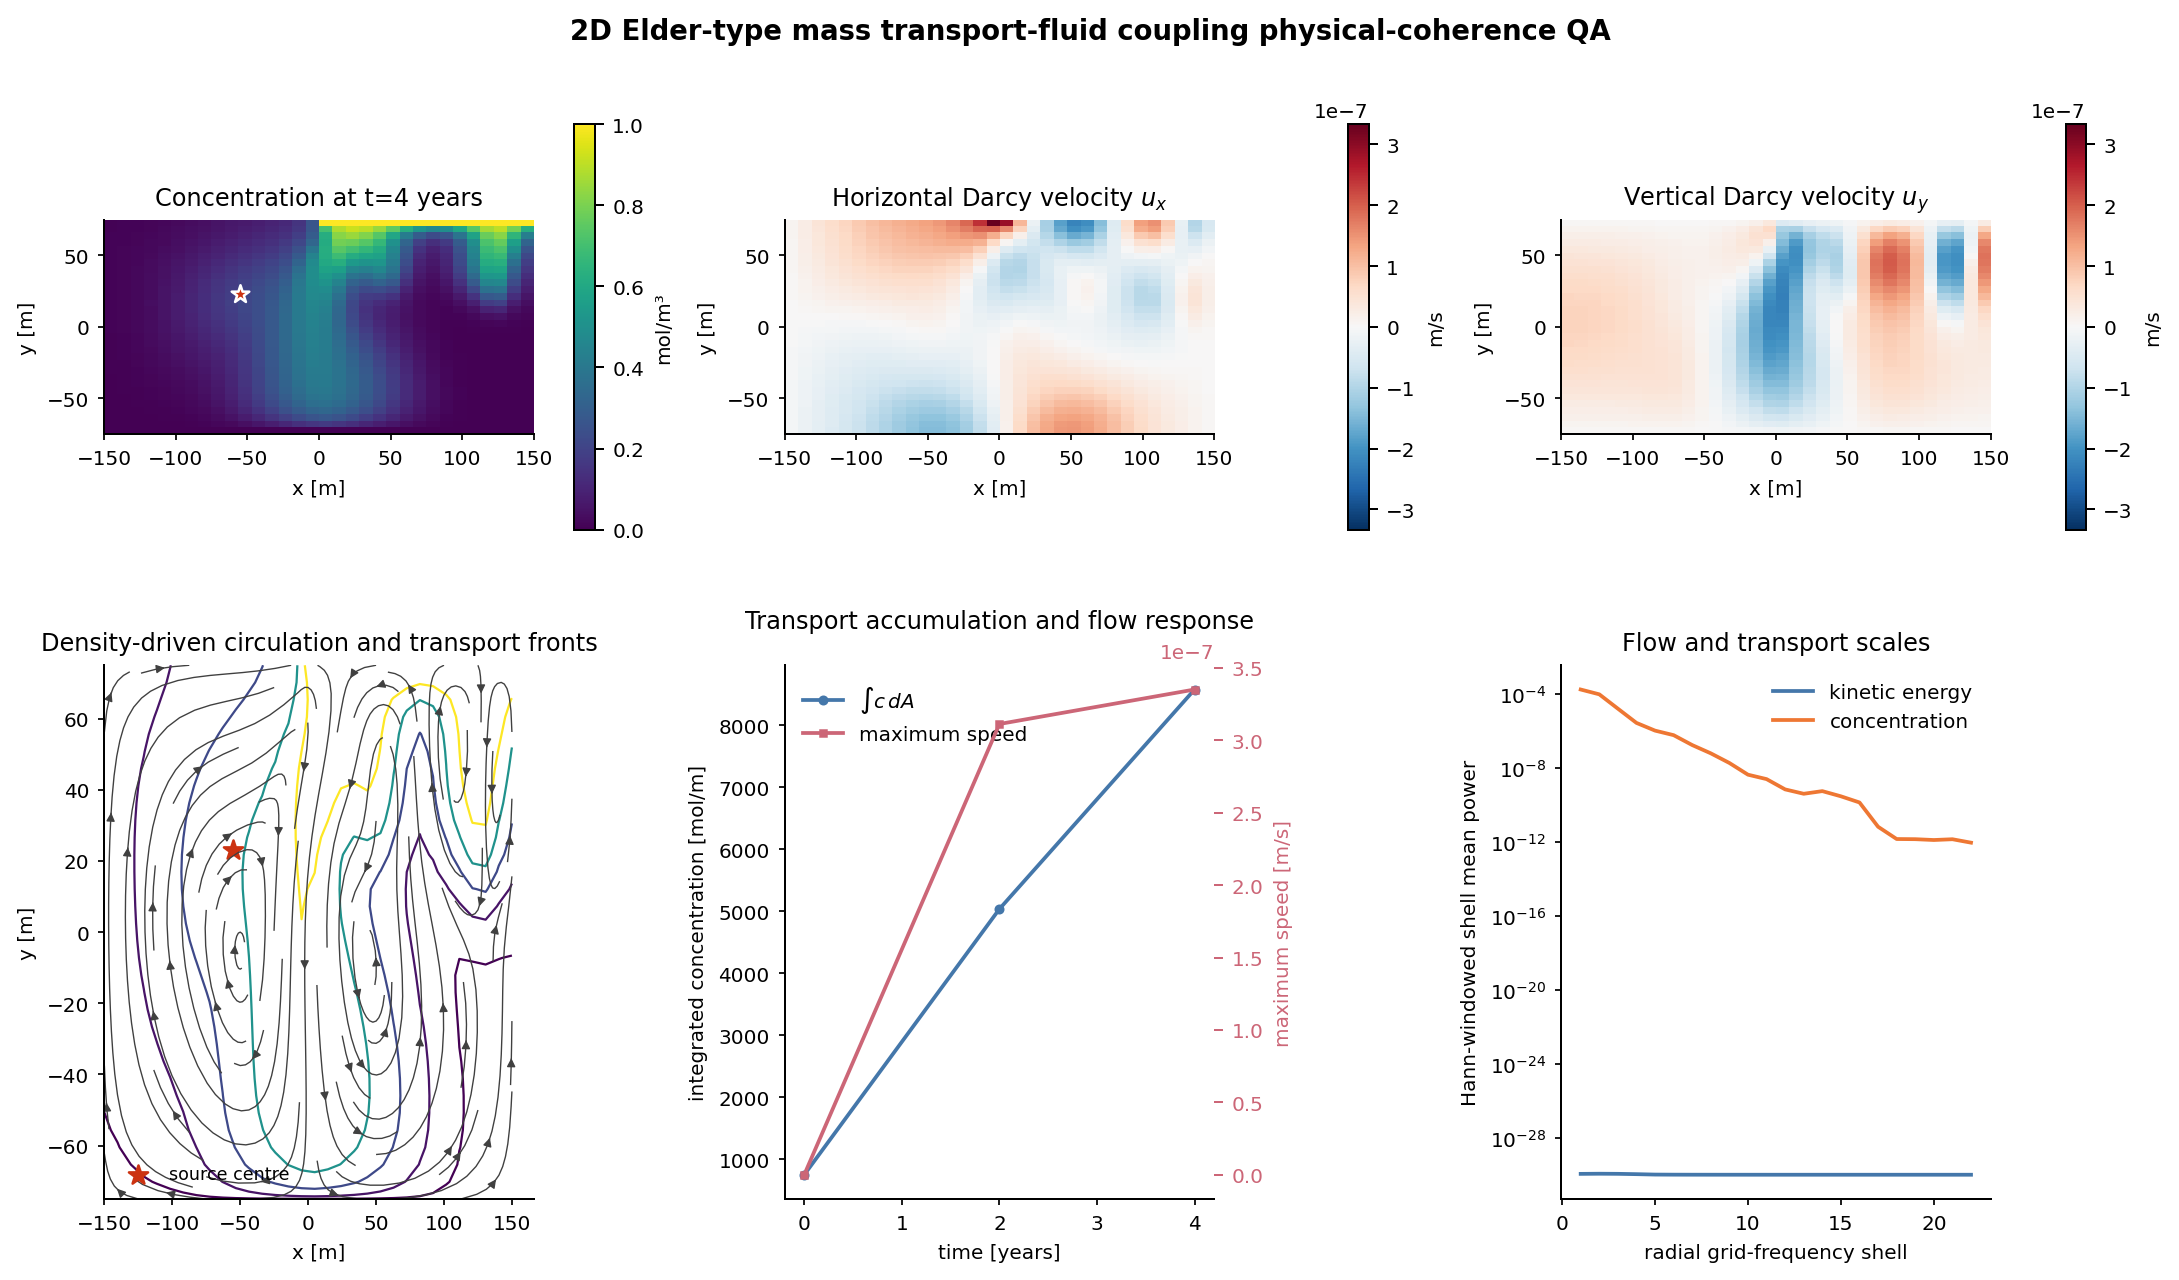

In [1]:
from IPython.display import Image as NotebookImage, display as notebook_display

demo_candidates = (
    Path("datagen/data/demos/mass_transport_fluid_demo_qa.png"),
    Path("../data/demos/mass_transport_fluid_demo_qa.png"),
)
demo_figure_path = next((path for path in demo_candidates if path.is_file()), None)
if demo_figure_path is None:
    print("Run the three validated pipeline commands above to recreate the demo figure.")
else:
    notebook_display(NotebookImage(filename=str(demo_figure_path)))
